In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
path = "/home/iailab42/g2-synthetic/PPG_FieldStudy/S1/S1.pkl"

with open(path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

print(data.keys())

dict_keys(['rpeaks', 'signal', 'label', 'activity', 'questionnaire', 'subject'])


### Preprocessing

In [3]:
bvp = data["signal"]["wrist"]["BVP"].flatten()
acc = data["signal"]["wrist"]["ACC"]
eda = data["signal"]["wrist"]["EDA"].flatten()
temp = data["signal"]["wrist"]["TEMP"].flatten()

print(bvp.shape)
print(acc.shape)
print(eda.shape)
print(temp.shape)

(589568,)
(294784, 3)
(36848,)
(36848,)


BVP = 64 Hz
Window = 8 seconds

64 x 8 = 512 

8 seconds is recommended

In [4]:
bvp_window = bvp[:512]
acc_window = acc[:256]
eda_window = eda[:32] 
temp_window = temp[:32] 

In [5]:
print("BVP :", bvp_window.shape)
print("ACC :", acc_window.shape)
print("EDA :", eda_window.shape)
print("TEMP:", temp_window.shape)

BVP : (512,)
ACC : (256, 3)
EDA : (32,)
TEMP: (32,)


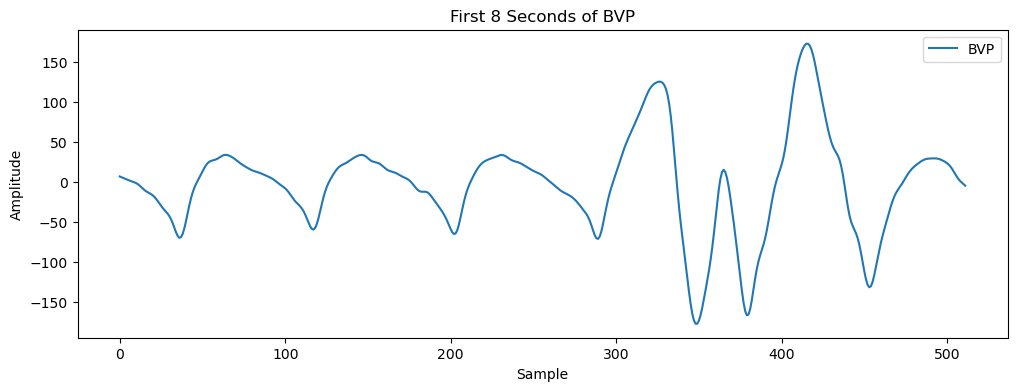

In [6]:
plt.figure(figsize=(12,4))
plt.plot(bvp_window, label="BVP")
plt.title("First 8 Seconds of BVP")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

Total 6 channels: BVP, ACC_X, ACC_Y, ACC_Z, EDA, TEMP.
Final input size (512, 6)

In [7]:
# Resampling function to standardize all signals to 512 samples
def resample_1d(signal, target_length=512):
    old_index = np.linspace(0,1, len(signal))
    new_index = np.linspace(0,1, target_length)

    interpolator = interp1d(old_index, signal, kind='linear')

    resampled_signal = interpolator(new_index)
    return resampled_signal

In [8]:
# ACC has 3 columns
acc_x_resampled = resample_1d(acc_window[:, 0], target_length=512)
acc_y_resampled = resample_1d(acc_window[:, 1], target_length=512)
acc_z_resampled = resample_1d(acc_window[:, 2], target_length=512)

acc_resampled = np.stack(
    [acc_x_resampled, acc_y_resampled, acc_z_resampled], axis=1
)

print("Resampled ACC shape:", acc_resampled.shape)

Resampled ACC shape: (512, 3)


In [9]:
eda_resampled = resample_1d(eda_window, target_length=512)

temp_resampled = resample_1d(temp_window, target_length=512)

print("Resampled EDA shape:", eda_resampled.shape)
print("Resampled TEMP shape:", temp_resampled.shape)

Resampled EDA shape: (512,)
Resampled TEMP shape: (512,)


In [10]:
bvp_col = bvp_window.reshape(-1, 1)
eda_col = eda_resampled.reshape(-1, 1)
temp_col = temp_resampled.reshape(-1, 1)

window_final = np.hstack([
    bvp_col,
    acc_resampled,
    eda_col,
    temp_col
])

print(window_final.shape)
print(window_final[:5])

(512, 6)
[[ 7.28       -0.765625   -0.078125    0.671875    4.722437   32.13      ]
 [ 6.33       -0.765625   -0.078125    0.66407779  4.72282562 32.13181996]
 [ 5.46       -0.765625   -0.078125    0.65628058  4.72321424 32.13363992]
 [ 4.6        -0.765625   -0.078125    0.66401663  4.72360287 32.13545988]
 [ 3.74       -0.765625   -0.078125    0.67181385  4.72399149 32.13727984]]


```markdown
window_final
      ↓
   Encoder
      ↓
 Latent Space
      ↓
   Decoder
      ↓
Reconstructed Window

### Resample the whole ACC, EDA, TEMP

In [11]:
target_length = len(bvp)

print("Original BVP length:", len(bvp))
print("Target length for resampling:", target_length)

acc_x_resampled_full = resample_1d(acc[:, 0], target_length=target_length)
acc_y_resampled_full = resample_1d(acc[:, 1], target_length=target_length)
acc_z_resampled_full = resample_1d(acc[:, 2], target_length=target_length)

eda_resampled_full = resample_1d(eda, target_length=target_length)
temp_resampled_full = resample_1d(temp, target_length=target_length)    

print("Resampled ACC shape:", acc_x_resampled_full.shape)
print("Resampled ACC shape:", acc_y_resampled_full.shape)
print("Resampled ACC shape:", acc_z_resampled_full.shape)
print("Resampled EDA shape:", eda_resampled_full.shape)
print("Resampled TEMP shape:", temp_resampled_full.shape)       

Original BVP length: 589568
Target length for resampling: 589568
Resampled ACC shape: (589568,)
Resampled ACC shape: (589568,)
Resampled ACC shape: (589568,)
Resampled EDA shape: (589568,)
Resampled TEMP shape: (589568,)


In [14]:
full_matrix = np.column_stack([
    bvp,
    acc_x_resampled_full,
    acc_y_resampled_full,
    acc_z_resampled_full,
    eda_resampled_full,
    temp_resampled_full
])

print("Full matrix shape:", full_matrix.shape)

print("First 5 rows of the full matrix:", full_matrix[:5])

Full matrix shape: (589568, 6)
First 5 rows of the full matrix: [[ 7.28       -0.765625   -0.078125    0.671875    4.722437   32.13      ]
 [ 6.33       -0.765625   -0.078125    0.66406251  4.72283736 32.13187495]
 [ 5.46       -0.765625   -0.078125    0.65625003  4.72323773 32.1337499 ]
 [ 4.6        -0.765625   -0.078125    0.66406246  4.72363809 32.13562486]
 [ 3.74       -0.765625   -0.078125    0.67187495  4.72403846 32.13749981]]


In [15]:
WINDOW_SIZE = 512
STEP_SIZE = 256 # 50% overlap

In [18]:
windows = []

for start in range(
    0,
    len(full_matrix) - WINDOW_SIZE + 1,
    STEP_SIZE
): 
    end = start + WINDOW_SIZE
    window = full_matrix[start:end]
    windows.append(window)

In [19]:
windows = np.array(windows)

print(windows.shape)

(2302, 512, 6)


In [20]:
print("Dataset shape:", windows.shape)

print("First window shape:", windows[0].shape)

print("Last window shape:", windows[-1].shape)

Dataset shape: (2302, 512, 6)
First window shape: (512, 6)
Last window shape: (512, 6)


In [21]:
save_path = "/home/iailab42/khans1/projects/data/s1_windows.npy"

np.save(save_path, windows)

print("Saved:", save_path)

Saved: /home/iailab42/khans1/projects/data/s1_windows.npy


In [22]:
loaded = np.load(save_path)

print(loaded.shape)

(2302, 512, 6)
